## Fire Detection Pipeline (ResNet18)

## 1. Setup & Konfiguration


In [30]:
# Imports
import os
import time
import shutil
from pathlib import Path
from collections import OrderedDict, Counter
from functools import partial
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from PIL import Image
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [31]:
# Pfade
DFIRE_DIR = "./D-Fire"                       # Originales D-Fire Dataset (YOLO-Format)
OUTPUT_DIR = "./classification_dataset"      # Output Preprocessing
MODEL_SAVE_PATH = "./best_model.pth"         # Checkpoint des besten Modells
PLOT_SAVE_PATH = "./training_plot.png"       # Trainings-Plot

# Preprocessing 
CLASS_MAP = {0: "fire", 1: "smoke"}
MIN_CROP_SIZE = 32

# Daten / Transforms 
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training-Hyperparameter 
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.2
NUM_WORKERS = 0  

In [32]:
# Device automatisch wählen (MPS / CUDA / CPU)
def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple MPS (Metal Performance Shaders)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA ({torch.cuda.get_device_name(0)})")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

device = get_device()

Using Apple MPS (Metal Performance Shaders)


## 2. Preprocessing — Klassifikations-Dataset

Liest das D-Fire YOLO-Dataset und sortiert Bilder in `fire/` und `no_fire/`. Bilder mit mindestens einer Bounding Box landen in `fire/`, Bilder ohne Label in `no_fire/`.

In [33]:
def parse_yolo_label(label_path):
    """Liest Koordinaten und Klasse aus einem YOLO-Label-File."""
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            x_c, y_c, w, h = map(float, parts[1:5])
            boxes.append((cls_id, x_c, y_c, w, h))
    return boxes


def crop_from_yolo(image: Image.Image, x_c, y_c, w, h, padding=0.1):
    """Schneidet eine Bounding Box aus einem Bild aus (mit Padding)."""
    img_w, img_h = image.size
    cx = x_c * img_w
    cy = y_c * img_h
    bw = w * img_w
    bh = h * img_h
    pad_x = bw * padding
    pad_y = bh * padding
    x1 = max(0, int(cx - bw / 2 - pad_x))
    y1 = max(0, int(cy - bh / 2 - pad_y))
    x2 = min(img_w, int(cx + bw / 2 + pad_x))
    y2 = min(img_h, int(cy + bh / 2 + pad_y))
    return image.crop((x1, y1, x2, y2))


def process_split(images_dir, labels_dir, output_dir, split_name):
    """Verarbeitet einen Split und sortiert Bilder in fire/ und no_fire/."""
    images_path = Path(images_dir)
    labels_path = Path(labels_dir)
    out_path = Path(output_dir) / split_name

    for cls_name in ["fire", "no_fire"]:
        (out_path / cls_name).mkdir(parents=True, exist_ok=True)

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_files = sorted(
        f for f in images_path.iterdir()
        if f.suffix.lower() in image_extensions
    )

    stats = {"fire": 0, "smoke": 0, "no_fire": 0, "skipped": 0}

    for img_file in image_files:
        label_file = labels_path / (img_file.stem + ".txt")
        boxes = parse_yolo_label(label_file)

        cls_name = "fire" if boxes else "no_fire"

        try:
            img = Image.open(img_file).convert("RGB")
            save_name = f"{img_file.stem}.jpg"
            img.save(out_path / cls_name / save_name, quality=95)
            stats[cls_name] += 1
        except Exception as e:
            print(f"  Warning: could not open {img_file.name}: {e}")
            stats["skipped"] += 1

    return stats

In [34]:
# Splits ermitteln und verarbeiten
dfire = Path(DFIRE_DIR)
splits = []
for split_name, out_name in [("train", "train"), ("test", "val")]:
    img_dir = dfire / split_name / "images"
    lbl_dir = dfire / split_name / "labels"
    if not img_dir.exists():
        img_dir = dfire / "images"
        lbl_dir = dfire / "labels"
    if not img_dir.exists():
        print(f"Skipping {split_name}: {img_dir} not found")
        continue
    splits.append((img_dir, lbl_dir, out_name))

all_stats = {}
if not splits:
    print(f"Error: No images found. Check that DFIRE_DIR points to the D-Fire root.")
else:
    for img_dir, lbl_dir, out_name in splits:
        print(f"\nProcessing {out_name} split...")
        print(f"  Images: {img_dir}")
        print(f"  Labels: {lbl_dir}")
        stats = process_split(img_dir, lbl_dir, OUTPUT_DIR, out_name)
        all_stats[out_name] = stats
        print(f"  Results: {stats}")
    print(f"\nDone! Classification dataset saved to: {os.path.abspath(OUTPUT_DIR)}")


Processing train split...
  Images: D-Fire/train/images
  Labels: D-Fire/train/labels
  Results: {'fire': 9388, 'smoke': 0, 'no_fire': 7833, 'skipped': 0}

Processing val split...
  Images: D-Fire/test/images
  Labels: D-Fire/test/labels
  Results: {'fire': 2301, 'smoke': 0, 'no_fire': 2005, 'skipped': 0}

Done! Classification dataset saved to: /Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/fire_detection/classification_dataset


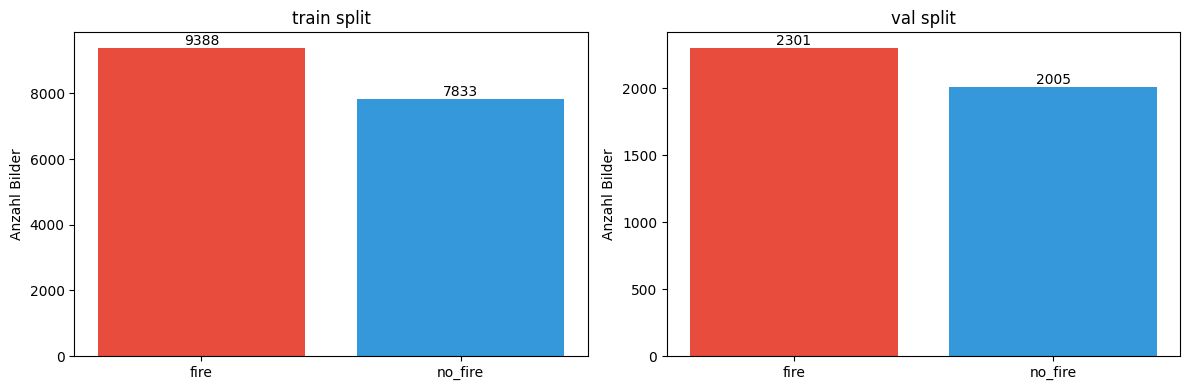

In [35]:
# Klassenverteilung visualisieren
if all_stats:
    fig, axes = plt.subplots(1, len(all_stats), figsize=(6 * len(all_stats), 4))
    if len(all_stats) == 1:
        axes = [axes]
    for ax, (split_name, stats) in zip(axes, all_stats.items()):
        classes = ["fire", "no_fire"]
        counts = [stats[c] for c in classes]
        ax.bar(classes, counts, color=["#e74c3c", "#3498db"])
        ax.set_title(f"{split_name} split")
        ax.set_ylabel("Anzahl Bilder")
        for i, c in enumerate(counts):
            ax.text(i, c, str(c), ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

Path: classification_dataset/train/fire/PublicDataset00139.jpg
Size: (480, 360)
Mode: RGB
Class: fire


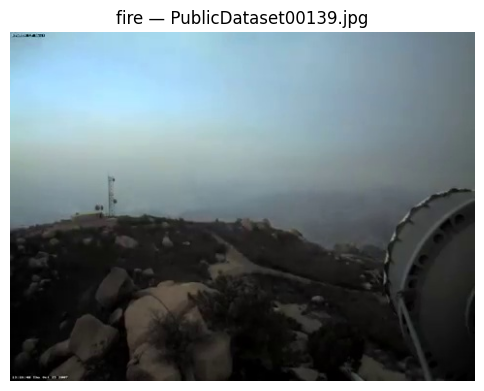

In [36]:
# Zufälliges Beispielbild

all_images = []
for cls in ["fire", "no_fire"]:
    folder = Path(OUTPUT_DIR) / "train" / cls
    if folder.exists():
        all_images.extend(list(folder.glob("*.jpg")))

if all_images:
    test_img_path = random.choice(all_images)
    img = Image.open(test_img_path)

    print(f"Path: {test_img_path}")
    print(f"Size: {img.size}")
    print(f"Mode: {img.mode}")
    print(f"Class: {test_img_path.parent.name}")

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"{test_img_path.parent.name} — {test_img_path.name}")
    plt.axis("off")
    plt.show()
else:
    print("Keine Bilder gefunden. Wurde das Preprocessing schon ausgeführt?")

## 3. Dataset & DataLoader

Transforms (Resize, Augmentation, Normalisierung) und Train/Val-Split.

In [37]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),  # 50% Wahrscheinlichkeit
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def get_dataloaders(data_dir: str, batch_size: int = 32,
                    val_split: float = 0.2, num_workers: int = 0):
    """
    Erstellt Train- und Val-DataLoader aus einem ImageFolder-Dataset.
    Gibt zurück: (train_loader, val_loader, class_names, n_classes)
    """
    full_dataset = datasets.ImageFolder(data_dir, transform=train_transforms)
    class_names = full_dataset.classes
    n_classes = len(class_names)

    n_val = int(len(full_dataset) * val_split)
    n_train = len(full_dataset) - n_val

    generator = torch.Generator().manual_seed(42)
    train_set, val_set = random_split(full_dataset, [n_train, n_val], generator=generator)

    # Eigenes Transform für Val-Set (ohne Augmentation)
    val_set.dataset = datasets.ImageFolder(data_dir, transform=val_transforms)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True)

    print(f"Dataset : {data_dir}")
    print(f"Classes : {n_classes}  {class_names}")
    print(f"Train   : {n_train}   Val: {n_val}")

    return train_loader, val_loader, class_names, n_classes

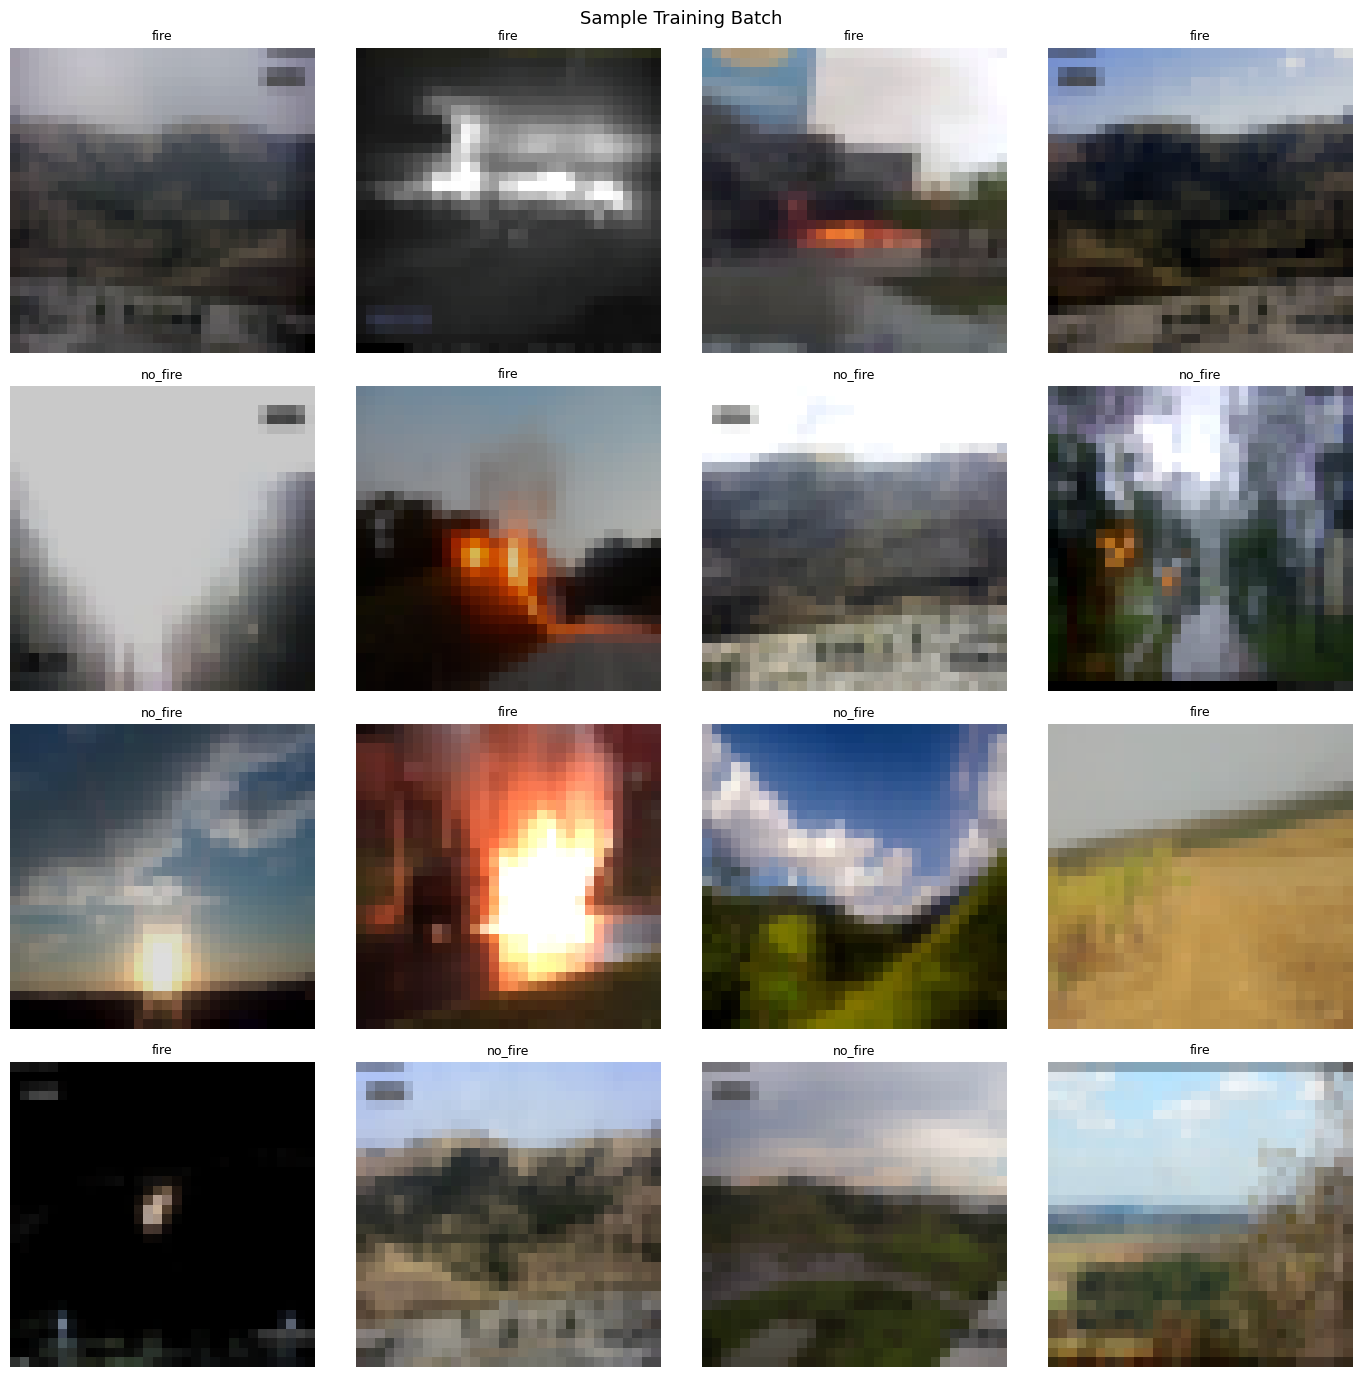

In [38]:
# Batch visualisieren 
def denormalise(tensor):
    """Macht die ImageNet-Normalisierung rückgängig für die Anzeige."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

try:
    images, labels = next(iter(train_loader))

    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    for ax, img, lbl in zip(axes.flatten(), images[:16], labels[:16]):
        img_np = denormalise(img).permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        ax.set_title(class_names[int(lbl.item())], fontsize=9)
        ax.axis("off")

    plt.suptitle("Sample Training Batch", fontsize=13)
    plt.tight_layout()
    plt.show()
except NameError:
    print("train_loader noch nicht definiert. Führe zuerst Abschnitt 5 aus.")

## 4. Modell — ResNet18

ResNet-Implementierung mit Encoder (Residual Blocks) + Decoder (Global Avg Pool + FC).

In [39]:
class Conv2dAuto(nn.Conv2d):
    """Conv2d mit automatischem 'same' Padding basierend auf der Kernel-Größe."""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)


conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)


class ResidualBlock(nn.Module):
    """Basis Residual Block: output = blocks(x) + shortcut(x)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.blocks = nn.Identity()
        self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x

    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels


class ResNetResidualBlock(ResidualBlock):
    """ResNet Residual Block mit Expansion und optionalem Downsampling."""
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion = expansion
        self.downsampling = downsampling
        self.conv = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn': nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )

    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion

    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels


def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    """Convolution gefolgt von BatchNorm."""
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn': nn.BatchNorm2d(out_channels)
    }))


class ResNetBasicBlock(ResNetResidualBlock):
    """Basic Block: zwei 3x3 conv/bn Layer mit ReLU."""
    expansion = 1

    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels, conv=self.conv,
                    bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels, conv=self.conv, bias=False),
        )


class ResNetBottleNeckBlock(ResNetResidualBlock):
    """Bottleneck Block: 1x1 -> 3x3 -> 1x1 conv/bn Layer."""
    expansion = 4

    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, expansion=4, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels, self.conv, kernel_size=1),
            activation(),
            conv_bn(self.out_channels, self.out_channels, self.conv,
                    kernel_size=3, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels, self.conv, kernel_size=1),
        )

In [40]:
class ResNetLayer(nn.Module):
    """Ein Layer, bestehend aus n gestapelten Residual Blocks."""
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock, n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs, downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )

    def forward(self, x):
        return self.blocks(x)


class ResNetEncoder(nn.Module):
    """ResNet Encoder: Gate (7x7 conv + pool) gefolgt von Residual Layers."""
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes

        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])

    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x


class ResNetDecoder(nn.Module):
    """Global Average Pool gefolgt von Fully Connected Classifier."""
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)

    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x


class ResNet(nn.Module):
    """Komplettes ResNet: Encoder + Decoder."""
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Factory Functions
def resnet18(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBasicBlock, depths=[2, 2, 2, 2])

def resnet34(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBasicBlock, depths=[3, 4, 6, 3])

def resnet50(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBottleNeckBlock, depths=[3, 4, 6, 3])

def resnet101(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBottleNeckBlock, depths=[3, 4, 23, 3])

def resnet152(in_channels, n_classes):
    return ResNet(in_channels, n_classes, block=ResNetBottleNeckBlock, depths=[3, 8, 36, 3])

## 5. Training

Training- und Validation-Loop, Best-Model-Checkpointing, abschließende Plots.

In [41]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [42]:
# DataLoader fürs Training holen (nutzt den train-Split aus dem Preprocessing)
train_data_dir = os.path.join(OUTPUT_DIR, "train")

train_loader, val_loader, class_names, n_classes = get_dataloaders(
    data_dir=train_data_dir,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    num_workers=NUM_WORKERS,
)

# Modell aufbauen
model = resnet18(in_channels=3, n_classes=n_classes).to(device)
print(f"\nModel: ResNet18  |  Parameters: {sum(p.numel() for p in model.parameters()):,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

Dataset : ./classification_dataset/train
Classes : 2  ['fire', 'no_fire']
Train   : 13777   Val: 3444

Model: ResNet18  |  Parameters: 11,177,538


In [43]:
# Training Loop
best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>10}  {'Val Acc':>9}  {'Time':>6}")
print("-" * 62)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step()

    elapsed = time.time() - t0
    marker = "*" if val_acc > best_val_acc else ""
    print(f"{epoch:5d}  {train_loss:10.4f}  {train_acc:8.2%}  {val_loss:10.4f}  {val_acc:8.2%}  {elapsed:5.1f}s {marker}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "class_names": class_names,
        }, MODEL_SAVE_PATH)

print(f"\nTraining complete. Best val accuracy: {best_val_acc:.2%}")
print(f"Model saved to: {os.path.abspath(MODEL_SAVE_PATH)}")


Epoch  Train Loss  Train Acc    Val Loss    Val Acc    Time
--------------------------------------------------------------
    1      0.6391    65.97%      0.5500    70.53%   75.8s *
    2      0.5406    71.82%      0.5026    75.52%   73.4s *
    3      0.4782    76.24%      0.4497    77.96%   76.9s *
    4      0.4251    79.76%      0.4319    79.53%   74.1s *
    5      0.3549    84.21%      0.3272    85.63%   74.4s *

Training complete. Best val accuracy: 85.63%
Model saved to: /Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/fire_detection/best_model.pth


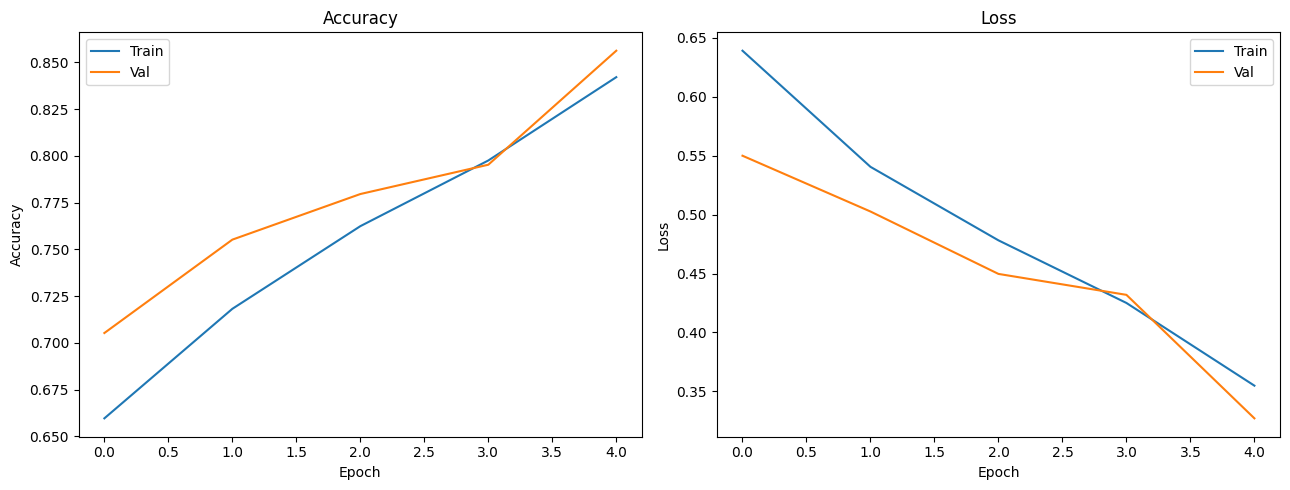

In [44]:
# Plots: Accuracy + Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(train_accs, label="Train")
ax1.plot(val_accs, label="Val")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(train_losses, label="Train")
ax2.plot(val_losses, label="Val")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.savefig(PLOT_SAVE_PATH)
plt.show()

## 6. Testen

Lädt das gespeicherte beste Modell und wertet aus: einzelne Bilder oder das komplette Validation-Set inkl. Confusion Matrix.

In [45]:
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def load_model(model_path, device):
    """Lädt Checkpoint und baut das Modell wieder auf."""
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    class_names = checkpoint["class_names"]
    n_classes = len(class_names)
    print(f"Model trained for {checkpoint['epoch']} epochs, val acc: {checkpoint['val_acc']:.2%}")
    print(f"Classes: {class_names}")

    model = resnet18(in_channels=3, n_classes=n_classes).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, class_names


def test_single_image(model, image_path, class_names, device):
    """Vorhersage für ein einzelnes Bild."""
    img = Image.open(image_path).convert("RGB")
    tensor = test_transforms(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = probs.argmax().item()

    print(f"\nImage: {image_path}")
    print(f"Prediction: {class_names[pred_idx]}")
    print(f"Confidence:")
    for i, name in enumerate(class_names):
        bar = "█" * int(probs[i].item() * 30)
        print(f"  {name:>10}: {probs[i].item():6.2%}  {bar}")

    # Bild anzeigen
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[pred_idx]} ({probs[pred_idx].item():.2%})")
    plt.axis("off")
    plt.show()


@torch.no_grad()
def test_validation_set(model, val_dir, class_names, device, batch_size=32):
    """Auswertung auf dem kompletten Val-Set mit Per-Class-Metriken."""
    val_dataset = datasets.ImageFolder(val_dir, transform=test_transforms)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=0, pin_memory=True)

    model.eval()
    correct = 0
    total = 0
    n_classes = len(class_names)

    class_correct = Counter()
    class_total = Counter()
    confusion = [[0] * n_classes for _ in range(n_classes)]

    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

        for true, pred in zip(labels.cpu().tolist(), preds.cpu().tolist()):
            class_total[true] += 1
            if true == pred:
                class_correct[true] += 1
            confusion[true][pred] += 1

    overall_acc = correct / total
    print(f"\nValidation Results")
    print(f"{'=' * 50}")
    print(f"Overall accuracy: {overall_acc:.2%}  ({correct}/{total})")

    print(f"\nPer-class accuracy:")
    for i, name in enumerate(class_names):
        ct = class_total.get(i, 0)
        cc = class_correct.get(i, 0)
        acc = cc / ct if ct > 0 else 0
        print(f"  {name:>10}: {acc:6.2%}  ({cc}/{ct})")

    print(f"\nConfusion matrix:")
    header = "            " + "  ".join(f"{n:>8}" for n in class_names)
    print(header)
    for i, name in enumerate(class_names):
        row = "  ".join(f"{confusion[i][j]:>8}" for j in range(n_classes))
        print(f"  {name:>10}  {row}")
    print(f"\n  (rows = true, columns = predicted)")

    # Confusion Matrix als Heatmap
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(confusion, cmap="Blues")
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix")
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, str(confusion[i][j]), ha="center", va="center",
                    color="white" if confusion[i][j] > max(map(max, confusion)) / 2 else "black")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    return overall_acc, confusion

### 6a. Komplettes Validation-Set auswerten

Model trained for 5 epochs, val acc: 85.63%
Classes: ['fire', 'no_fire']


/Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Validation Results
Overall accuracy: 86.14%  (3709/4306)

Per-class accuracy:
        fire: 86.01%  (1979/2301)
     no_fire: 86.28%  (1730/2005)

Confusion matrix:
                fire   no_fire
        fire      1979       322
     no_fire       275      1730

  (rows = true, columns = predicted)


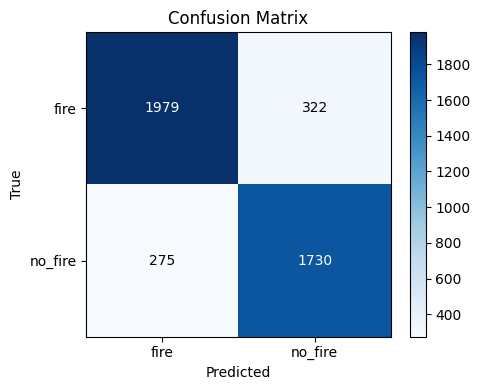

In [47]:
trained_model, class_names = load_model(MODEL_SAVE_PATH, device)

val_dir = os.path.join(OUTPUT_DIR, "val")
if os.path.exists(val_dir):
    test_validation_set(trained_model, val_dir, class_names, device, batch_size=BATCH_SIZE)
else:
    print(f"Val-Ordner nicht gefunden: {val_dir}")

### 6b. ROC-Curve

/Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


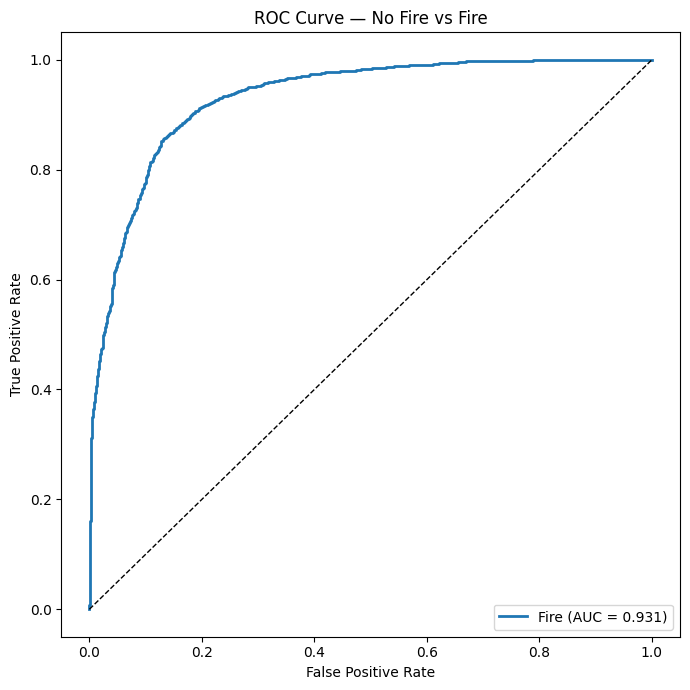

AUC: 0.9315


In [48]:

val_dir = os.path.join(OUTPUT_DIR, "val")
val_dataset = datasets.ImageFolder(val_dir, transform=test_transforms)
val_loader_eval = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)

fire_idx = class_names.index("fire")
true_labels = []
pred_probs = []

trained_model.eval()
with torch.no_grad():
    for images, labels in val_loader_eval:
        images = images.to(device)
        outputs = trained_model(images)
        probs = torch.softmax(outputs, dim=1)[:, fire_idx]
        true_labels.extend(labels.numpy())
        pred_probs.extend(probs.cpu().numpy())

true_labels = np.array(true_labels)
pred_probs  = np.array(pred_probs)
true_binary = (true_labels == fire_idx).astype(int)

fpr, tpr, _ = roc_curve(true_binary, pred_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, label=f"Fire (AUC = {roc_auc:.3f})", lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — No Fire vs Fire")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=120)
plt.show()

print(f"AUC: {roc_auc:.4f}")

### 6c. Sample-Bildern (grün = richtig, rot = falsch)

/Users/sophiapaoli/Nextcloud/Documents/Master/Semester_2/Praxisseminar/Explaining_Image_Classification/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


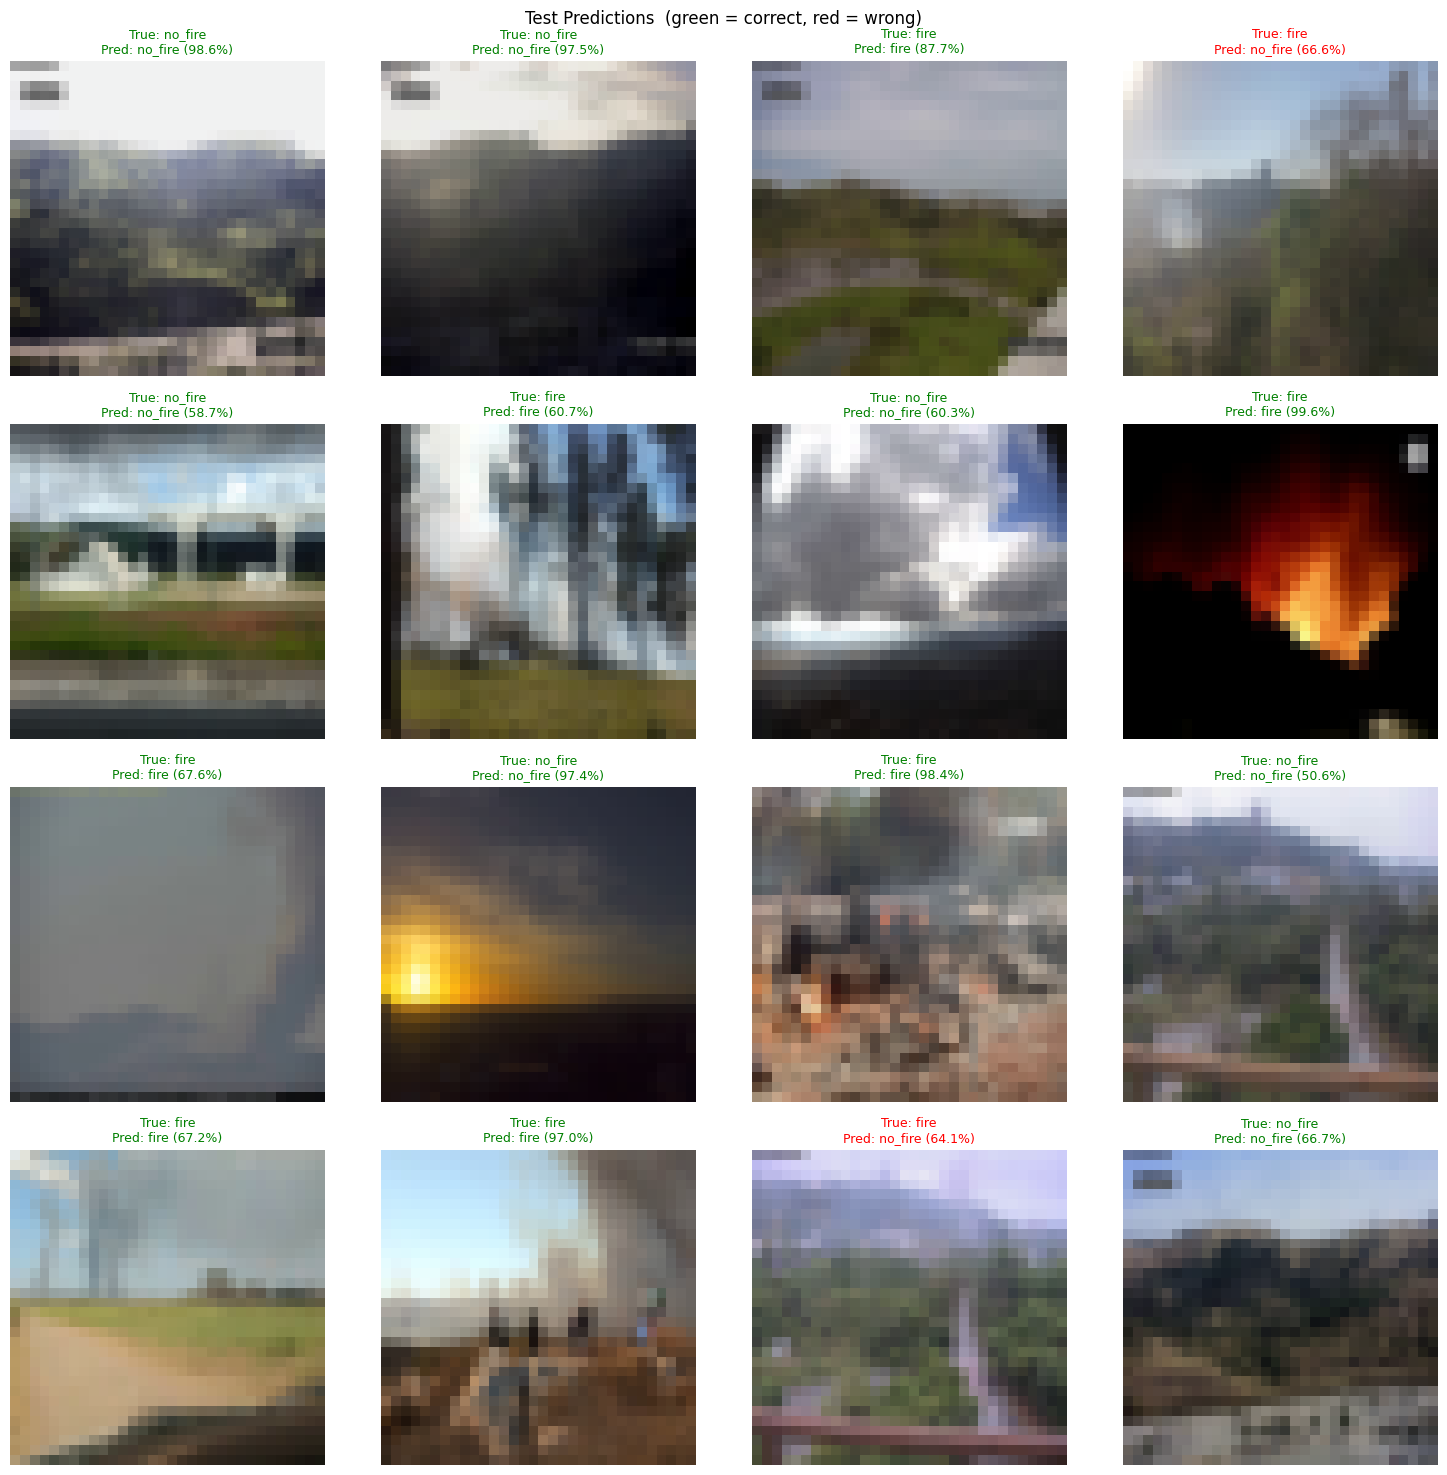

In [49]:
# Predictions auf 16 Sample-Bildern (grün = richtig, rot = falsch)
sample_loader = DataLoader(val_dataset, batch_size=16, shuffle=True,
                            num_workers=0, pin_memory=True)
sample_images, sample_labels = next(iter(sample_loader))

trained_model.eval()
with torch.no_grad():
    outputs = trained_model(sample_images.to(device))
    sample_probs = torch.softmax(outputs, dim=1).cpu().numpy()
    sample_preds = sample_probs.argmax(axis=1)

fig, axes = plt.subplots(4, 4, figsize=(15, 15))
for ax, img, true_lbl, pred_lbl, probs in zip(axes.flatten(),
                                                sample_images,
                                                sample_labels,
                                                sample_preds,
                                                sample_probs):
    img_np = denormalise(img).permute(1, 2, 0).numpy()
    true_str = class_names[int(true_lbl.item())]
    pred_str = class_names[int(pred_lbl)]
    confidence = probs[pred_lbl]
    colour = "green" if pred_lbl == int(true_lbl.item()) else "red"

    ax.imshow(img_np)
    ax.set_title(f"True: {true_str}\nPred: {pred_str} ({confidence:.1%})",
                 color=colour, fontsize=9)
    ax.axis("off")

plt.suptitle("Test Predictions  (green = correct, red = wrong)", fontsize=12)
plt.tight_layout()
plt.savefig("test_predictions.png", dpi=120)
plt.show()

### 6d. Einzelnes Bild testen

Pfad anpassen, dann Zelle ausführen.

In [ ]:
# Pfad zu einem Testbild
test_image_path = "./some_fire.jpg"  # <-- hier eigenes Bild eintragen

if os.path.exists(test_image_path):
    test_single_image(trained_model, test_image_path, class_names, device)
else:
    print(f"Bild nicht gefunden: {test_image_path}")

Bild nicht gefunden: ./some_fire.jpg
